# Loading Dependencies

In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks,optimizers
import numpy as np
import random, os, glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Seet function for fix results
SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Data Collection

In [3]:
#loading the dataset
dataset_dir="/Users/datascientist/Downloads/Rice Disease/Rice_Leaf_AUG (1)"

In [4]:
class_names=[cls for cls in sorted(os.listdir(dataset_dir)) if not cls.startswith(".") and os.path.isdir(os.path.join(dataset_dir, cls))]
print("Classes:",class_names)
all_images,all_labels=[],[]
for idx, cls in enumerate(class_names):
    files=glob.glob(os.path.join(dataset_dir,cls,"*.jpg"))+\
    glob.glob(os.path.join(dataset_dir,cls,"*.png"))  
    all_images.extend(files)
    all_labels.extend([idx]*len(files))
all_images=np.array(all_images)
all_labels=np.array(all_labels)

Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


# Spliting the dataset 

### splitted dataset into 80-20% ratio , 80% for training and remaininig for validation

In [5]:
#Load dataset in an easy way
train_ds=tf.keras.utils.image_dataset_from_directory(dataset_dir,validation_split=0.2,subset="training",seed=SEED,image_size=(128,128),batch_size=32)
val_ds=tf.keras.utils.image_dataset_from_directory(dataset_dir,validation_split=0.2,subset="validation",seed=SEED,image_size=(128,128),batch_size=32)


# Class names from folder names
class_names=train_ds.class_names
print("Classes:",class_names)


Found 3830 files belonging to 6 classes.
Using 3064 files for training.
Found 3830 files belonging to 6 classes.
Using 766 files for validation.
Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


# Data Preprocessing

In [6]:
#Normalize images into 0,1 range
normalization=tf.keras.layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y:(normalization(x),y))
val_ds=val_ds.map(lambda x,y:(normalization(x),y))

#Improving performance by prefetching
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)
val_ds=val_ds.prefetch(tf.data.AUTOTUNE)

# Data Augmentation
Data augmentation helps improve model accuracy by creating variations of training images

In [7]:
# Data Augmentation Layer
data_augmentation=models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# CNN MODEL

In [8]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)), 
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 126, 126, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 61, 61, 64)       

In [9]:
# setting the callbacks to save the best model, early stopping, and learning rate reduction
callback=[
    callbacks.EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True),
    callbacks.ModelCheckpoint("models/cnn_best_model.h5",save_best_only=True,monitor="val_loss"),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)]

In [10]:
# train the model over 50 epochs (with early stopping)
history=model.fit(train_ds,validation_data=val_ds,epochs=50,callbacks=callback)

Epoch 1/50
96/96 [==============================] - 34s 321ms/step - loss: 1.7171 - accuracy: 0.4145 - val_loss: 4.3599 - val_accuracy: 0.1736 - lr: 0.0010
Epoch 2/50
96/96 [==============================] - 27s 278ms/step - loss: 1.3266 - accuracy: 0.5251 - val_loss: 6.8098 - val_accuracy: 0.1762 - lr: 0.0010
Epoch 3/50
96/96 [==============================] - 28s 282ms/step - loss: 1.2305 - accuracy: 0.5525 - val_loss: 4.3688 - val_accuracy: 0.1958 - lr: 0.0010
Epoch 4/50
96/96 [==============================] - 30s 302ms/step - loss: 1.1225 - accuracy: 0.5953 - val_loss: 4.2632 - val_accuracy: 0.2898 - lr: 0.0010
Epoch 5/50
96/96 [==============================] - 32s 316ms/step - loss: 1.0380 - accuracy: 0.6129 - val_loss: 1.4982 - val_accuracy: 0.5052 - lr: 0.0010
Epoch 6/50
96/96 [==============================] - 29s 296ms/step - loss: 0.9688 - accuracy: 0.6335 - val_loss: 0.8338 - val_accuracy: 0.6789 - lr: 0.0010
Epoch 7/50
96/96 [==============================] - 29s 290ms/st

# Evaluate the model

In [11]:
loss,acc=model.evaluate(val_ds)
print(f"\nFinal Validation Accuracy:{acc*100:.2f}%")

24/24 [==============================] - 6s 224ms/step - loss: 0.2499 - accuracy: 0.9230

Final Validation Accuracy:92.30%


# Graphical representation of model performance

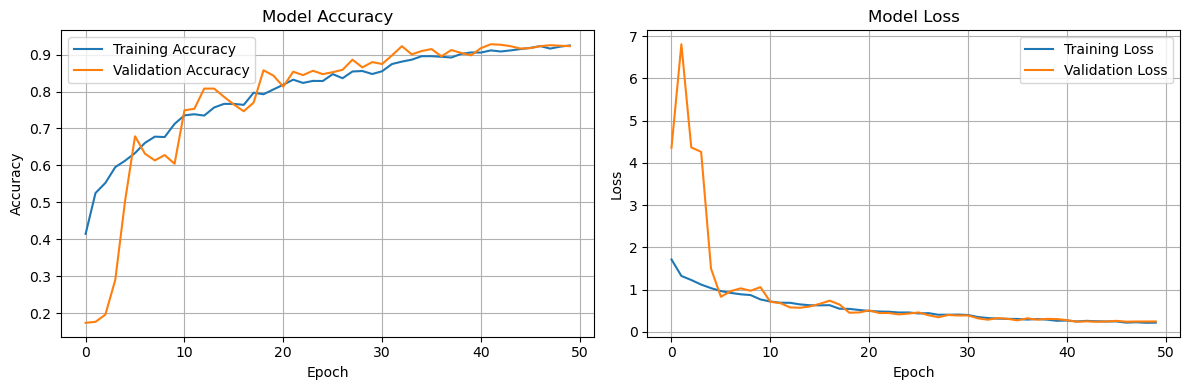

In [12]:
plt.figure(figsize=(12,4))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('models/training_history.png')
plt.show()
